## GWAS-графики


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2


def read_regenie(filepath):
    """Чтение файла REGENIE, восстановление P и -log10(P)."""
    df = pd.read_csv(filepath, sep="\s+")
    if "LOG10P" in df.columns:
        df["P"] = np.power(10, -df["LOG10P"])
    elif "PVAL" in df.columns:
        df["P"] = df["PVAL"]
    elif "CHISQ" in df.columns:
        df["P"] = chi2.sf(df["CHISQ"], 1)
    else:
        raise ValueError("Нужны столбцы LOG10P, PVAL или CHISQ.")
    df["LOGP"] = -np.log10(df["P"])
    return df


def manhattan_plot_multi(
    df,
    title="Manhattan Plot",
    genomewide=-np.log10(5e-8),
    suggestive=-np.log10(1e-5),
    color_list=["#1f77b4", "#ff7f0e"],
):
    """
    Manhattan plot для любого количества хромосом.
    df должен содержать столбцы: CHROM (int/str), GENPOS (int), LOGP (float)
    """
    # Сортируем по хромосоме и позиции
    df = df.sort_values(["CHROM", "GENPOS"]).reset_index(drop=True)

    # Уникальные хромосомы в порядке появления
    chroms = df["CHROM"].unique()

    # Строим непрерывную координату
    df["CUM_POS"] = 0
    chrom_centers = []
    offset = 0
    for chrom in chroms:
        mask = df["CHROM"] == chrom
        if mask.sum() == 0:
            continue
        # Добавляем смещение к позициям этой хромосомы
        df.loc[mask, "CUM_POS"] = df.loc[mask, "GENPOS"] + offset
        # Запоминаем центр хромосомы (среднее арифметическое мин и макс позиций)
        chrom_min = df.loc[mask, "CUM_POS"].min()
        chrom_max = df.loc[mask, "CUM_POS"].max()
        chrom_centers.append((chrom_min + chrom_max) / 2)
        # Следующее смещение = текущий максимум + небольшой зазор (для красоты)
        offset = chrom_max + 1_000_000  # зазор 1 Мб, можно регулировать

    # Рисуем
    plt.figure(figsize=(16, 6))
    for i, chrom in enumerate(chroms):
        mask = df["CHROM"] == chrom
        color = color_list[i % len(color_list)]
        plt.scatter(
            df.loc[mask, "CUM_POS"],
            df.loc[mask, "LOGP"],
            color=color,
            s=4,
            label=f"Chr {chrom}" if i == 0 else "",
        )

    # Горизонтальные линии значимости
    if genomewide:
        plt.axhline(
            y=genomewide,
            color="red",
            linestyle="-",
            linewidth=1,
            label="Genome-wide (5e-8)",
        )
    if suggestive:
        plt.axhline(
            y=suggestive,
            color="blue",
            linestyle="--",
            linewidth=1,
            label="Suggestive (1e-5)",
        )

    # Подписи хромосом по центру
    plt.xticks(chrom_centers, [str(c) for c in chroms], rotation=0)
    plt.xlabel("Chromosome")
    plt.ylabel("-log10(p)")
    plt.title(title)

    # Легенда: показываем только линии значимости, убираем дублирующиеся метки хромосом
    handles, labels = plt.gca().get_legend_handles_labels()
    # Оставляем уникальные подписи (для хромосом оставляем только один label)
    unique = {}
    for handle, label in zip(handles, labels):
        if label not in unique and label != "Chr 1":
            unique[label] = handle
    plt.legend(
        unique.values(), unique.keys(), loc="upper right", frameon=True, framealpha=None
    )
    plt.tight_layout()
    return plt.gcf()

In [8]:
from scipy.stats import beta
import numpy as np


def qq_plot(df, title="QQ Plot", ci=0.95):
    """
    QQ-plot для p-value из результатов GWAS.
    df должен содержать столбец 'P' (p-value).
    """
    pvals = df["P"].dropna().values
    pvals[pvals == 0] = np.finfo(float).tiny  # заменяем нули на минимальное float
    n = len(pvals)

    observed = -np.log10(np.sort(pvals))
    expected = -np.log10((np.arange(1, n + 1) - 0.5) / n)

    # 95% доверительный интервал
    alpha = 1 - ci
    lower = -np.log10(
        beta.ppf(alpha / 2, np.arange(1, n + 1), n - np.arange(1, n + 1) + 1)
    )
    upper = -np.log10(
        beta.ppf(1 - alpha / 2, np.arange(1, n + 1), n - np.arange(1, n + 1) + 1)
    )

    # Коэффициент инфляции λ
    # λ = median(observed χ²) / 0.456 (для 1 df)
    chisq = chi2.isf(pvals, 1)
    lambda_gc = np.median(chisq) / chi2.ppf(0.5, 1)

    plt.figure(figsize=(6, 6))
    plt.fill_between(
        expected, lower, upper, color="gray", alpha=0.2, label=f"{int(ci * 100)}% CI"
    )
    plt.scatter(expected, observed, s=4, color="black", alpha=0.6)
    max_val = max(expected.max(), observed.max()) * 1.05
    plt.plot([0, max_val], [0, max_val], "r--", linewidth=1, label="y = x")

    plt.xlabel("Expected -log10(p)")
    plt.ylabel("Observed -log10(p)")
    plt.title(title)
    plt.legend(loc="upper left", frameon=False)

    # Добавляем λ на график
    plt.text(
        0.05,
        0.80,
        f"λ = {lambda_gc:.3f}",
        transform=plt.gca().transAxes,
        fontsize=12,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )
    plt.tight_layout()
    return plt.gcf()

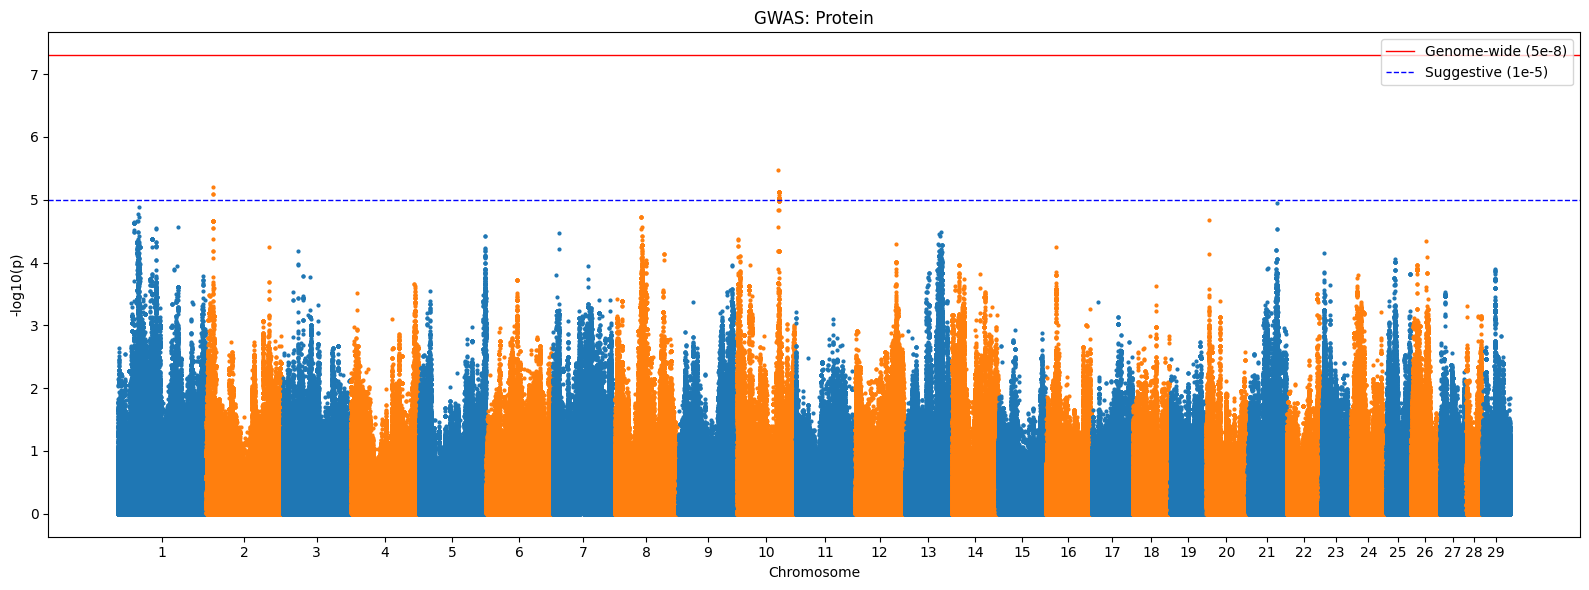

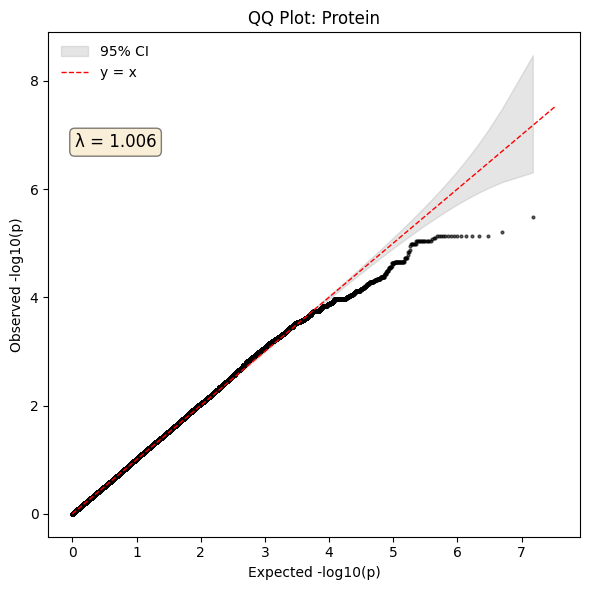

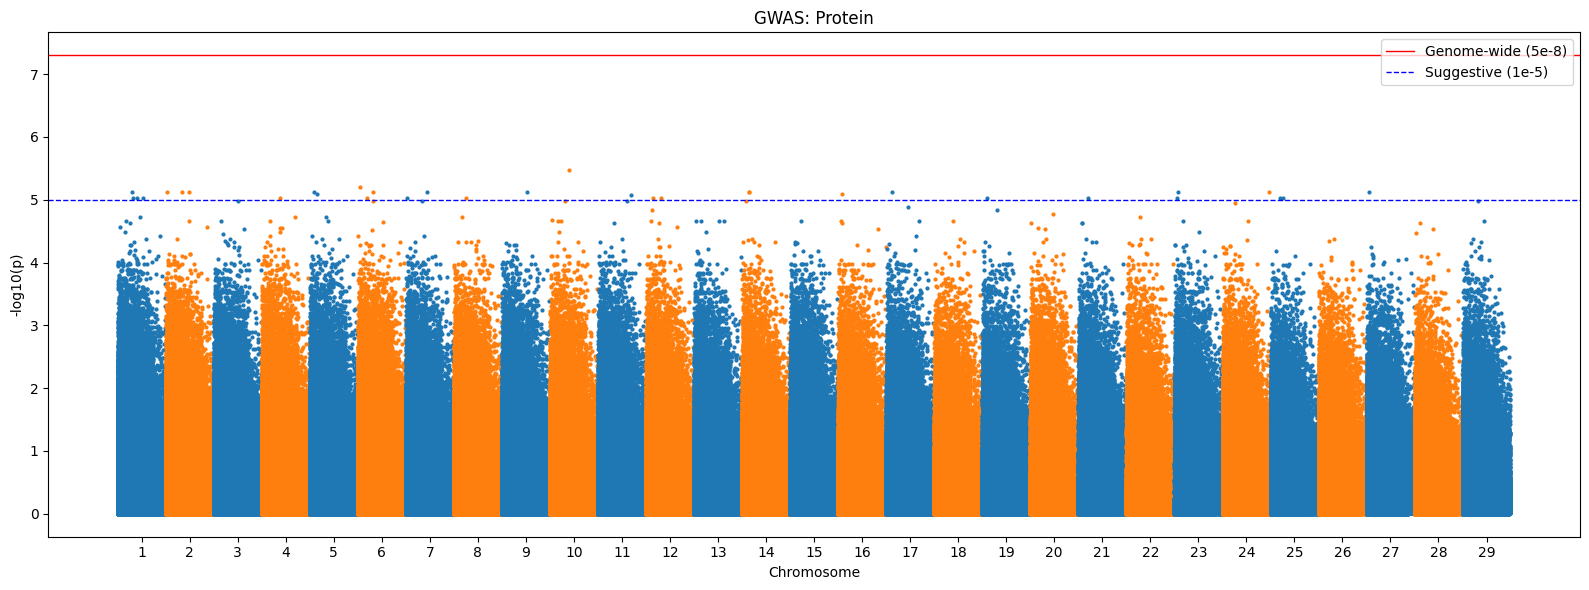

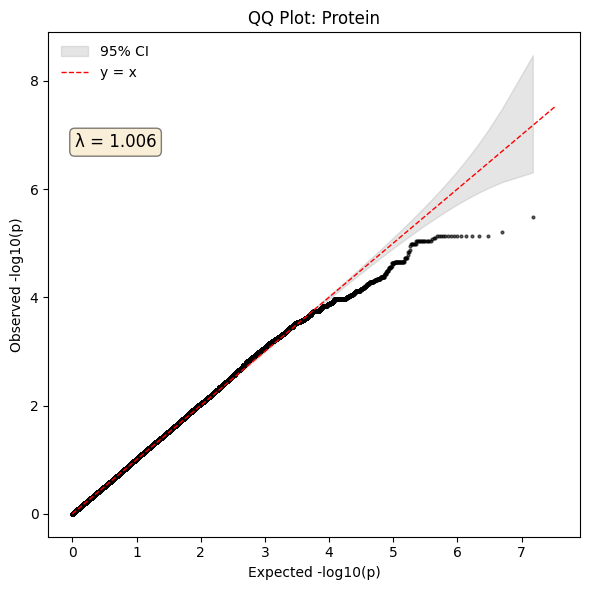

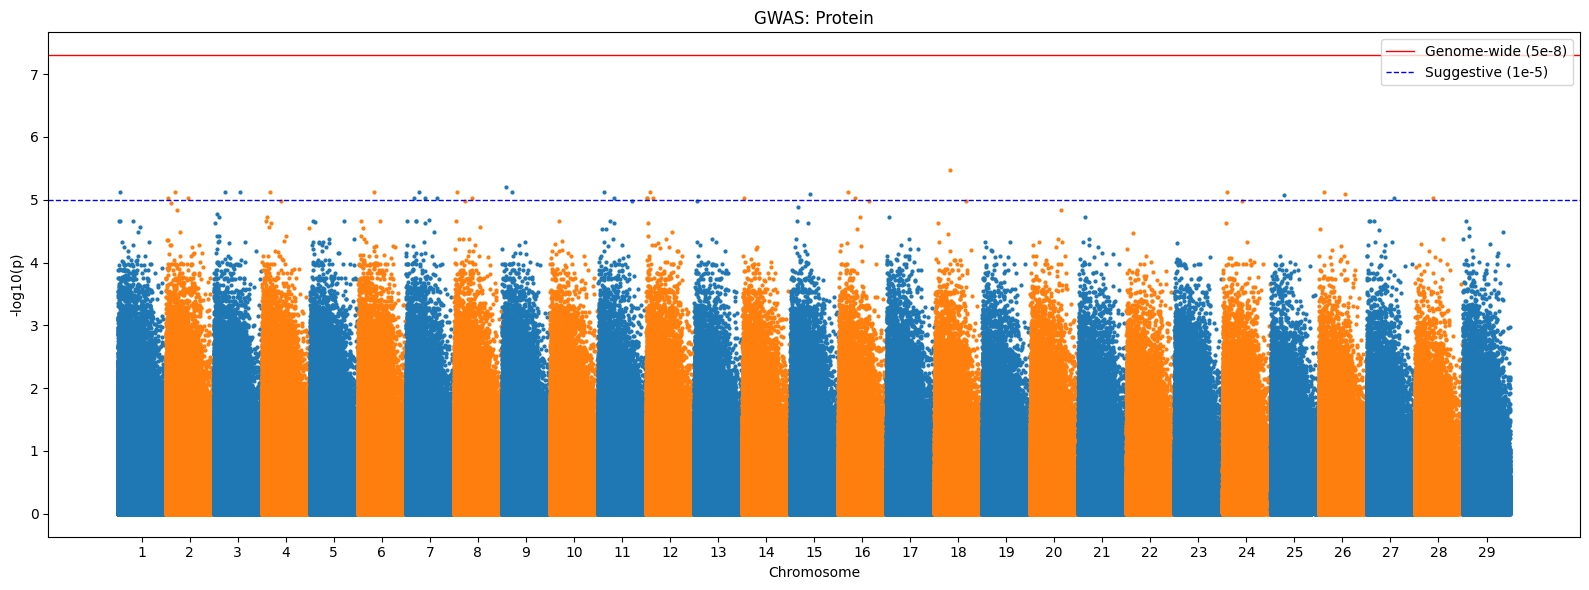

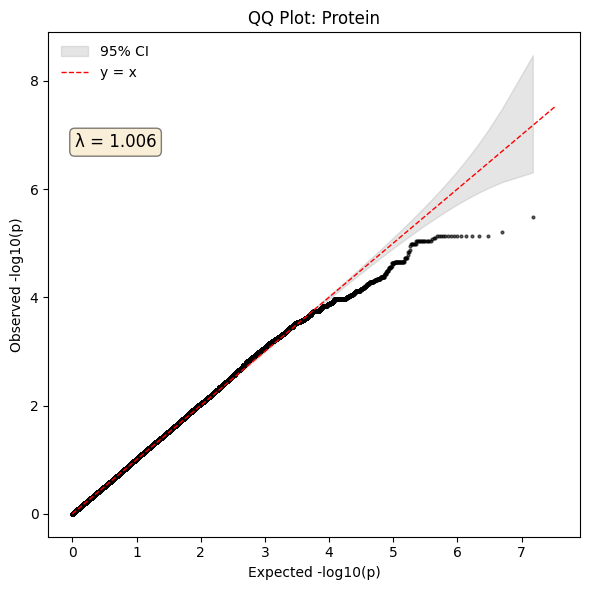

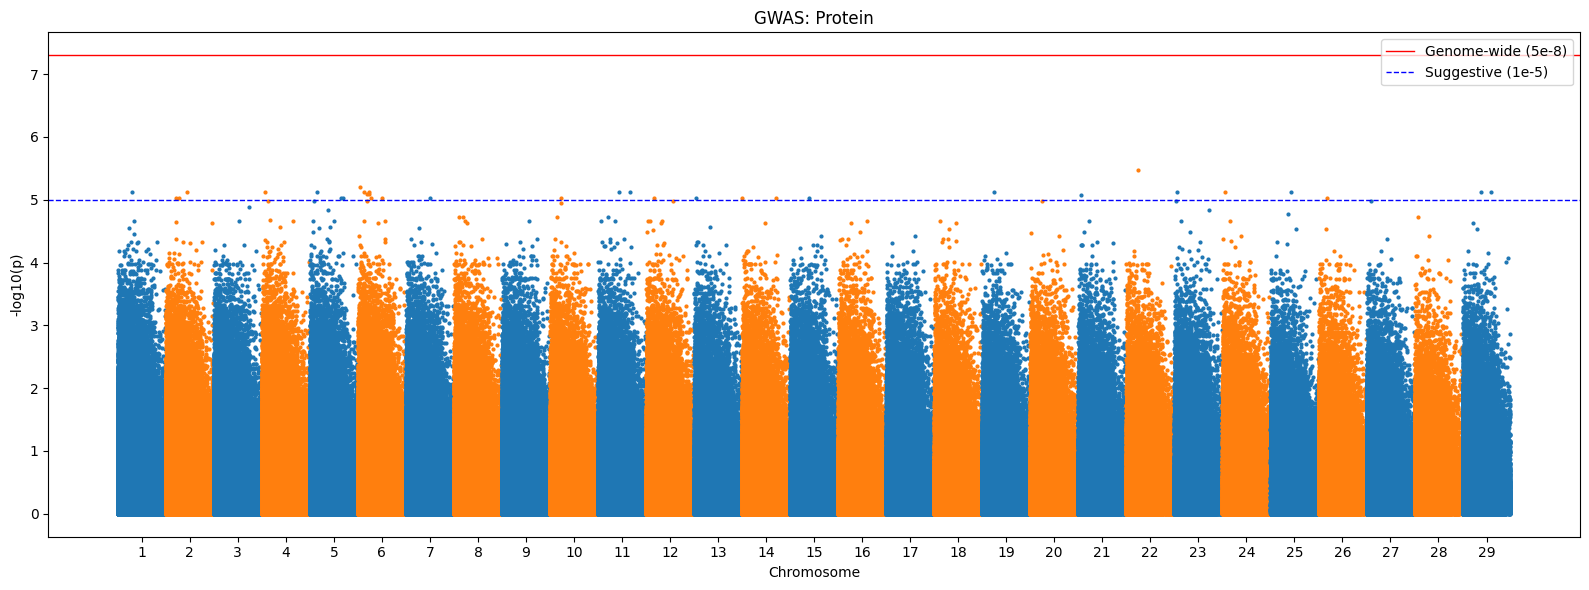

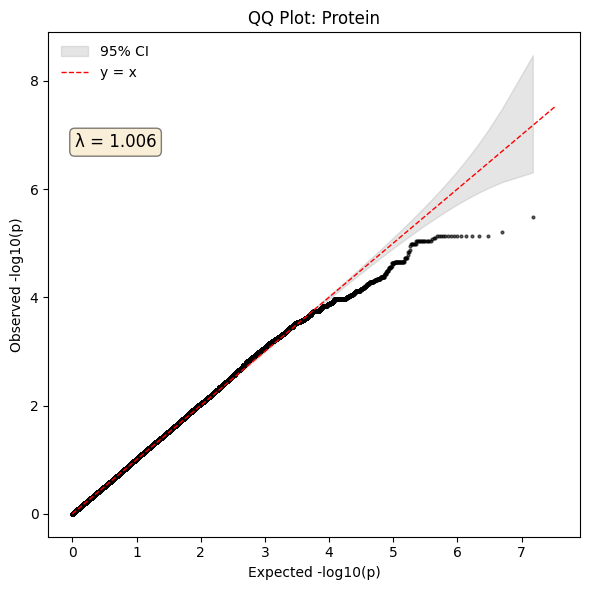

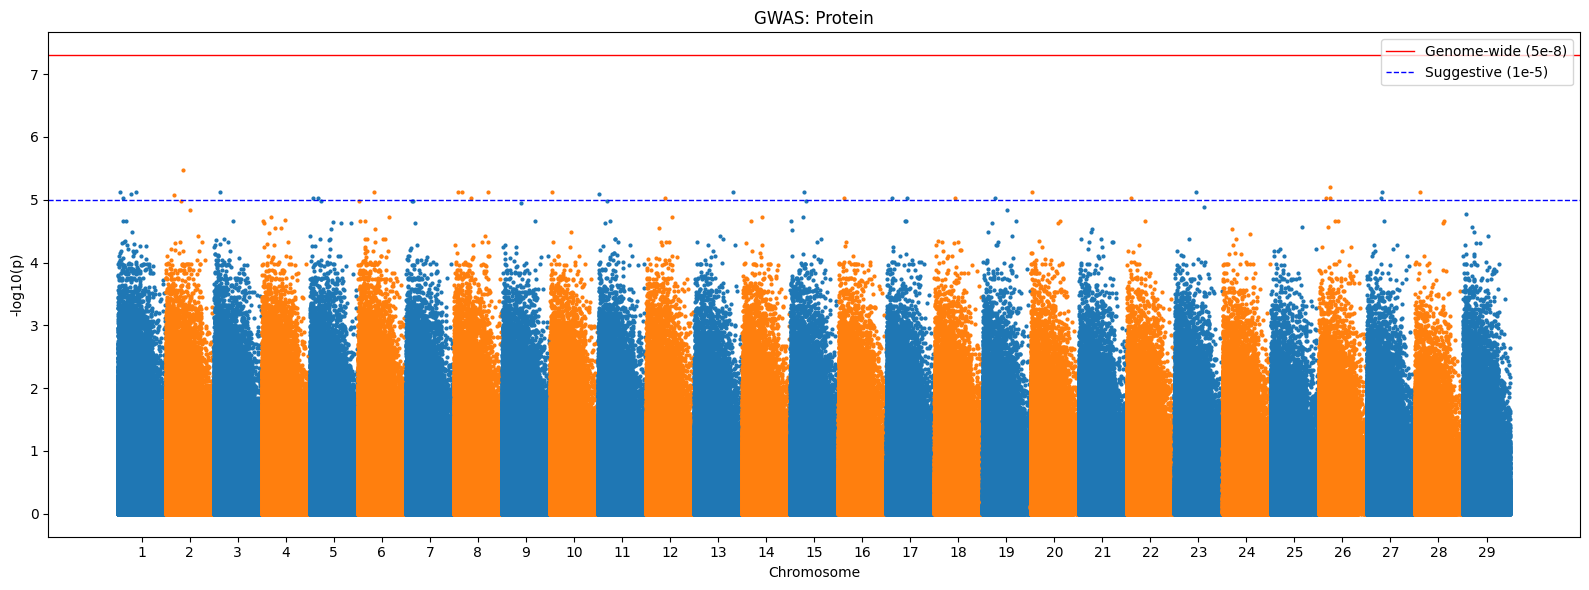

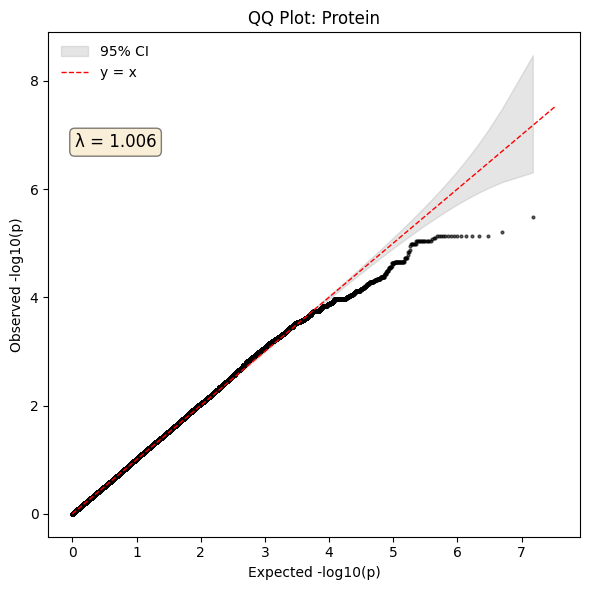

In [15]:
from IPython.display import display
from pathlib import Path

all_phenotype_file = [
    file
    for file in Path(
        "/scratch/storageA/zaleski_bulls/bulls-vcf-pipeline/results/gwas"
    ).iterdir()
    if file.is_file() and file.suffix == ".regenie"
]

for path_gwas in all_phenotype_file[1:2]:
    path_gwas = str(path_gwas)
    df_all = read_regenie(path_gwas)

    phenotype = (
        path_gwas.split("/")[-1]
        .removeprefix("final_gwas_results_")
        .removesuffix(".regenie")
    )
    fig_man = manhattan_plot_multi(df_all, title=f"GWAS: {phenotype}")
    fig_qq = qq_plot(df_all, title=f"QQ Plot: {phenotype}")
    np.random.shuffle(df_all["CHROM"].values)
    np.random.shuffle(df_all["GENPOS"].values)
    fig_man = manhattan_plot_multi(df_all, title=f"GWAS: {phenotype}")
    # fig_man.savefig("manhattan_yield.png", dpi=150)

    # QQ-plot (тот же df, все хромосомы)
    fig_qq = qq_plot(df_all, title=f"QQ Plot: {phenotype}")
    np.random.shuffle(df_all["CHROM"].values)
    np.random.shuffle(df_all["GENPOS"].values)
    fig_man = manhattan_plot_multi(df_all, title=f"GWAS: {phenotype}")
    # fig_man.savefig("manhattan_yield.png", dpi=150)

    # QQ-plot (тот же df, все хромосомы)
    fig_qq = qq_plot(df_all, title=f"QQ Plot: {phenotype}")
    np.random.shuffle(df_all["CHROM"].values)
    np.random.shuffle(df_all["GENPOS"].values)
    fig_man = manhattan_plot_multi(df_all, title=f"GWAS: {phenotype}")
    # fig_man.savefig("manhattan_yield.png", dpi=150)

    # QQ-plot (тот же df, все хромосомы)
    fig_qq = qq_plot(df_all, title=f"QQ Plot: {phenotype}")
    np.random.shuffle(df_all["CHROM"].values)
    np.random.shuffle(df_all["GENPOS"].values)
    fig_man = manhattan_plot_multi(df_all, title=f"GWAS: {phenotype}")
    # fig_man.savefig("manhattan_yield.png", dpi=150)

    # QQ-plot (тот же df, все хромосомы)
    fig_qq = qq_plot(df_all, title=f"QQ Plot: {phenotype}")
    # fig_qq.savefig("qq_yield.png", dpi=150)

plt.show()

In [10]:
import pandas as pd
import numpy as np

suggestive_threshold = 1e-5

df = pd.read_csv(
    "/scratch/storageA/zaleski_bulls/bulls-vcf-pipeline/results/gwas/final_gwas_results_Yield.regenie",
    sep="\s+",
)
if "LOG10P" in df.columns:
    df["P"] = np.power(10, -df["LOG10P"])
elif "PVAL" in df.columns:
    df["P"] = df["PVAL"]
elif "CHISQ" in df.columns:
    df["P"] = chi2.sf(df["CHISQ"], 1)
else:
    raise ValueError("Нужны столбцы LOG10P, PVAL или CHISQ.")
df["LOGP"] = -np.log10(df["P"])

# Отбираем SNP, где P < порога
sig_df = df[df["P"] < suggestive_threshold].copy()

# Сортируем по P-value (от самых значимых к менее значимым)
sig_df = sig_df.sort_values("P")


In [11]:
from IPython.display import display

sig_df["BP1"] = None
sig_df["BP2"] = None

for i in sig_df["CHROM"].unique():
    df = pd.read_csv(
        f"/scratch/storageA/zaleski_bulls/bulls-vcf-pipeline/results/gwas/chr{i}/snps_blocks.blocks.det",
        sep="\s+",
    )
    df["SNPS"] = df["SNPS"].str.split("|")

    # print(df["CHR"].iloc[0], df["BP1"].iloc[0], df["BP2"].iloc[0])  # df["SNPS"]
    for index, row in sig_df[sig_df["CHROM"] == i].iterrows():
        df_filtered = df[(df["BP2"] >= row["GENPOS"]) & (df["BP1"] <= row["GENPOS"])]
        if len(df_filtered) >= 1 and row["ID"] in df_filtered["SNPS"].iloc[0]:
            sig_df.at[index, "BP1"] = df_filtered["BP1"].iloc[0]
            sig_df.at[index, "BP2"] = df_filtered["BP2"].iloc[0]
sig_df

,CHROM,GENPOS,ID,ALLELE0,ALLELE1,A1FREQ,N,TEST,BETA,SE,CHISQ,LOG10P,EXTRA,P,LOGP,BP1,BP2
6812308,25,14706284,25_14706284_C_T,T,C,0.466200,429,ADD,-493.474,101.8300,23.4840,5.89978,NaN,0.000001,5.89978,14688050,14735195
6812303,25,14702855,25_14702855_G_A,G,A,0.465035,429,ADD,-489.473,102.3510,22.8705,5.76123,NaN,0.000002,5.76123,14688050,14735195
6812320,25,14718748,25_14718748_G_C,C,G,0.465035,429,ADD,-489.473,102.3510,22.8705,5.76123,NaN,0.000002,5.76123,14688050,14735195
6812321,25,14719667,25_14719667_A_G,G,A,0.465035,429,ADD,-489.473,102.3510,22.8705,5.76123,NaN,0.000002,5.76123,14688050,14735195
6812295,25,14697149,25_14697149_C_T,C,T,0.465035,429,ADD,-489.473,102.3510,22.8705,5.76123,NaN,0.000002,5.76123,14688050,14735195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4349239,13,61371081,13_61371081_T_G,T,G,0.157343,429,ADD,558.604,126.0570,19.6370,5.02854,NaN,0.000009,5.02854,61327077,61444875
4349220,13,61342274,13_61342274_G_A,G,A,0.157343,429,ADD,558.604,126.0570,19.6370,5.02854,NaN,0.000009,5.02854,61327077,61444875
4349202,13,61286033,13_61286033_T_C,T,C,0.157343,429,ADD,558.604,126.0570,19.6370,5.02854,NaN,0.000009,5.02854,61126894,61326891
4349212,13,61324133,13_61324133_A_G,A,G,0.157343,429,ADD,558.604,126.0570,19.6370,5.02854,NaN,0.000009,5.02854,61126894,61326891


In [12]:
print(len(sig_df["BP1"].unique()))

sig_df = sig_df.sort_values("P")

group_bp1 = sig_df.groupby(by="BP1")

ld_snp = sig_df.drop_duplicates(subset=["BP1"], keep="first")
ld_snp = ld_snp.dropna(subset=["BP1", "BP2"])
ld_snp
# pd.DataFrame.dropna()

8


,CHROM,GENPOS,ID,ALLELE0,ALLELE1,A1FREQ,N,TEST,BETA,SE,CHISQ,LOG10P,EXTRA,P,LOGP,BP1,BP2
6812308,25,14706284,25_14706284_C_T,T,C,0.466200,429,ADD,-493.474,101.830,23.4840,5.89978,NaN,0.000001,5.89978,14688050,14735195
4347559,13,60440611,13_60440611_A_T,A,T,0.228438,429,ADD,503.083,108.953,21.3207,5.41059,NaN,0.000004,5.41059,60428373,60447605
4347685,13,60567073,13_60567073_T_C,T,C,0.245921,429,ADD,478.519,106.075,20.3504,5.19058,NaN,0.000006,5.19058,60555258,60573508
4347351,13,60326267,13_60326267_G_A,G,A,0.395105,429,ADD,455.756,101.436,20.1872,5.15353,NaN,0.000007,5.15353,60325652,60326813
4346600,13,60070612,13_60070612_C_A,C,A,0.390443,429,ADD,446.808,100.156,19.9015,5.08865,NaN,0.000008,5.08865,60054928,60085589
4349239,13,61371081,13_61371081_T_G,T,G,0.157343,429,ADD,558.604,126.057,19.6370,5.02854,NaN,0.000009,5.02854,61327077,61444875
4349202,13,61286033,13_61286033_T_C,T,C,0.157343,429,ADD,558.604,126.057,19.6370,5.02854,NaN,0.000009,5.02854,61126894,61326891


## Получение генов из ensembl

In [5]:
import sys

sys.path.insert(0, "/scratch/storageA/zaleski_bulls/bulls-vcf-pipeline/src")
import importlib
from preprocessing import tools_ensembl

importlib.reload(tools_ensembl)
# или, если preprocessing не пакет, а папка без __init__.py:
# sys.path.insert(0, '/scratch/storageA/zaleski_bulls/bulls-vcf-pipeline/src/preprocessing')
# import tools_ensembl


for _, row in ld_snp.iterrows():
    print(row["CHROM"], row["GENPOS"], row["BP1"], row["BP2"], row["ID"])
    tools_ensembl.run(row["CHROM"], row["GENPOS"], row["BP1"], row["BP2"])
    print()

25 14706284 14688050 14735195 25_14706284_C_T

13 60440611 60428373 60447605 13_60440611_A_T

13 60567073 60555258 60573508 13_60567073_T_C
Ближайший белок-кодирующий ген: CSNK2A1
Расстояние: 1214 п.н.
Описание: casein kinase 2 alpha 1 [Source:NCBI gene (formerly Entrezgene);Acc:282419]
[(1214,
  {'assembly_name': 'ARS-UCD2.0',
   'biotype': 'protein_coding',
   'canonical_transcript': 'ENSBTAT00000074832.3',
   'description': 'casein kinase 2 alpha 1 [Source:NCBI gene (formerly '
                  'Entrezgene);Acc:282419]',
   'end': 60565859,
   'external_name': 'CSNK2A1',
   'feature_type': 'gene',
   'gene_id': 'ENSBTAG00000012341',
   'id': 'ENSBTAG00000012341',
   'logic_name': 'ensembl',
   'seq_region_name': '13',
   'source': 'ensembl',
   'start': 60507727,
   'strand': 1,
   'version': 8})]

13 60326267 60325652 60326813 13_60326267_G_A

13 60070612 60054928 60085589 13_60070612_C_A

13 61371081 61327077 61444875 13_61371081_T_G
Ближайший белок-кодирующий ген: MYLK2
Расстоян

## Получение QTL

In [6]:
import pandas as pd
import re

# --- 1. Загружаем файл, не ограничивая колонки ---
bed_gz_path = "/scratch/storageA/zaleski_bulls/bulls-vcf-pipeline/data/Animal_QTLdb_release59_cattleARS_UCD2.bed.gz"

# Читаем все строки, игнорируя комментарии
df_raw = pd.read_csv(
    bed_gz_path,
    sep="\t",
    comment="#",
    header=None,
    compression="gzip",
    low_memory=False,
)

print(f"Загружено строк: {len(df_raw)}")
print("Первые 2 строки (все колонки):")
print(df_raw.head(2).to_string())

# Определим правильные индексы колонок
# Стандартный BED: chrom (0), chromStart (1), chromEnd (2), name (3), score (4), strand (5)
# но в этом файле дополнительные колонки: thickStart (6), thickEnd (7), itemRgb (8) и ещё
# Убедимся, что в колонках 1 и 2 действительно числа
df_raw.iloc[:, 1] = pd.to_numeric(df_raw.iloc[:, 1], errors="coerce")
df_raw.iloc[:, 2] = pd.to_numeric(df_raw.iloc[:, 2], errors="coerce")
df_raw = df_raw.dropna(subset=[1, 2])
df_raw[1] = df_raw[1].astype(int)
df_raw[2] = df_raw[2].astype(int)

# Переименуем для удобства
df_qtl = df_raw.rename(
    columns={
        0: "chrom",
        1: "chromStart",
        2: "chromEnd",
        3: "name",
        4: "score",
        5: "strand",
    }
)

# Приводим хромосомы к единому виду: убираем 'Chr.' и делаем строкой
df_qtl["chrom"] = df_qtl["chrom"].astype(str).str.replace("Chr.", "", regex=False)
print("\nУникальные хромосомы:", df_qtl["chrom"].unique()[:20])

# --- 2. Ваши локусы ---
loci = [
    # ("1", 62695470, 62846219),
    # ("1", 152488915, 152513681),
    # ("3", 49386861, 49912847),
    # ("10", 47946757, 48046428),
    # ("13", 60507727, 60565859),
    # ("13", 61220111, 61369684),
]

for _, row in ld_snp.iterrows():
    loci.append((str(row["CHROM"]), row["BP1"], row["BP2"]))

# --- 3. Поиск пересечений ---
overlaps = {}
for chrom, start, end in loci:
    mask = (
        (df_qtl["chrom"] == str(chrom))
        & (df_qtl["chromStart"] < end)
        & (df_qtl["chromEnd"] > start)
    )
    overlapping = df_qtl[mask].copy()
    overlaps[(chrom, start, end)] = overlapping

# --- 4. Вывод ---
for (chrom, start, end), qtl_df in overlaps.items():
    print(f"\n{'=' * 60}")
    print(f"Локус chr{chrom}: {start:,} - {end:,}")
    if qtl_df.empty:
        print("  ❌ Перекрывающихся QTL не найдено.")
    else:
        print(f"  ✅ Найдено {len(qtl_df)} QTL:")
        for _, row in qtl_df.iterrows():
            trait = (
                row["name"].split("(")[0].strip() if "(" in row["name"] else row["name"]
            )
            print(f"    - {trait}")
            print(f"      Координаты: {row['chromStart']:,} - {row['chromEnd']:,}")

Загружено строк: 195876
Первые 2 строки (все колонки):
      0       1       2                                                      3   4  5       6       7  8  9  10 11
0  Chr.X  269909  269919                               Shear force QTL (152532) NaN  +  269909  269919  .  .  .  .
1  Chr.X  573551  573561  Kidney, pelvic, and heart fat percentage QTL (152055) NaN  +  573551  573561  .  .  .  .

Уникальные хромосомы: ['X' '1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15'
 '16' '17' '18' '19']

Локус chr25: 14,688,050 - 14,735,195
  ❌ Перекрывающихся QTL не найдено.

Локус chr13: 60,428,373 - 60,447,605
  ❌ Перекрывающихся QTL не найдено.

Локус chr13: 60,555,258 - 60,573,508
  ❌ Перекрывающихся QTL не найдено.

Локус chr13: 60,325,652 - 60,326,813
  ✅ Найдено 1 QTL:
    - Milk riboflavin content QTL
      Координаты: 60,326,808 - 60,326,818

Локус chr13: 60,054,928 - 60,085,589
  ❌ Перекрывающихся QTL не найдено.

Локус chr13: 61,327,077 - 61,444,875
  ✅ Найдено 10 QT

## Получение по SNP vep - возможное влияние

In [7]:
from time import sleep
import json
import pprint
import requests, sys

server = "https://rest.ensembl.org"
ext = "/vep/bos_taurus/region"
headers = {"Content-Type": "application/json", "Accept": "application/json"}


for bp1_value, block_df in group_bp1:
    display(block_df)
    # ["21  26960070  rs116645811 G A . . .", "21  26965148  rs1135638 G A . . ." ]
    data = []
    for _, row in block_df.iterrows():
        data.append(
            f"{row['CHROM']} {row['GENPOS']} {row['ID']} {row['ALLELE0']} {row['ALLELE1']} . . ."
        )

    payload = json.dumps(
        {
            "variants": data,
            "regulatory": 1,
            "canonical": 1,
            "numbers": 1,
            "domains": 1,
            "pick": 1,
        }
    )

    r = requests.post(server + ext, headers=headers, data=payload)

    if not r.ok:
        r.raise_for_status()
        sys.exit()

    decoded = r.json()
    pprint.pprint(decoded)
    sleep(15)

,CHROM,GENPOS,ID,ALLELE0,ALLELE1,A1FREQ,N,TEST,BETA,SE,CHISQ,LOG10P,EXTRA,P,LOGP,BP1,BP2
6812308,25,14706284,25_14706284_C_T,T,C,0.466200,429,ADD,-493.474,101.830,23.4840,5.89978,NaN,0.000001,5.89978,14688050,14735195
6812303,25,14702855,25_14702855_G_A,G,A,0.465035,429,ADD,-489.473,102.351,22.8705,5.76123,NaN,0.000002,5.76123,14688050,14735195
6812320,25,14718748,25_14718748_G_C,C,G,0.465035,429,ADD,-489.473,102.351,22.8705,5.76123,NaN,0.000002,5.76123,14688050,14735195
6812321,25,14719667,25_14719667_A_G,G,A,0.465035,429,ADD,-489.473,102.351,22.8705,5.76123,NaN,0.000002,5.76123,14688050,14735195
6812295,25,14697149,25_14697149_C_T,C,T,0.465035,429,ADD,-489.473,102.351,22.8705,5.76123,NaN,0.000002,5.76123,14688050,14735195
6812300,25,14700730,25_14700730_C_T,C,T,0.465035,429,ADD,-489.473,102.351,22.8705,5.76123,NaN,0.000002,5.76123,14688050,14735195
6812319,25,14717896,25_14717896_T_C,C,T,0.465035,429,ADD,-489.473,102.351,22.8705,5.76123,NaN,0.000002,5.76123,14688050,14735195
6812283,25,14692006,25_14692006_G_A,G,A,0.466200,429,ADD,-479.298,102.208,21.9910,5.56235,NaN,0.000003,5.56235,14688050,14735195
6812285,25,14692843,25_14692843_T_C,C,T,0.466200,429,ADD,-479.298,102.208,21.9910,5.56235,NaN,0.000003,5.56235,14688050,14735195
6812284,25,14692231,25_14692231_T_C,C,T,0.466200,429,ADD,-479.298,102.208,21.9910,5.56235,NaN,0.000003,5.56235,14688050,14735195


[{'allele_string': 'T/C',
  'assembly_name': 'ARS-UCD2.0',
  'end': 14706284,
  'id': '25_14706284_C_T',
  'input': '25 14706284 25_14706284_C_T T C . . .',
  'intergenic_consequences': [{'consequence_terms': ['intergenic_variant'],
                               'impact': 'MODIFIER',
                               'variant_allele': 'C'}],
  'most_severe_consequence': 'intergenic_variant',
  'seq_region_name': '25',
  'start': 14706284,
  'strand': 1},
 {'allele_string': 'G/A',
  'assembly_name': 'ARS-UCD2.0',
  'colocated_variants': [{'allele_string': 'G/A',
                          'end': 14702855,
                          'id': 'rs43112965',
                          'start': 14702855,
                          'strand': 1,
                          'variation_id': 19110181}],
  'end': 14702855,
  'id': '25_14702855_G_A',
  'input': '25 14702855 25_14702855_G_A G A . . .',
  'intergenic_consequences': [{'consequence_terms': ['intergenic_variant'],
                               'i

,CHROM,GENPOS,ID,ALLELE0,ALLELE1,A1FREQ,N,TEST,BETA,SE,CHISQ,LOG10P,EXTRA,P,LOGP,BP1,BP2
4346600,13,60070612,13_60070612_C_A,C,A,0.390443,429,ADD,446.808,100.156,19.9015,5.08865,NaN,0.000008,5.08865,60054928,60085589


[{'allele_string': 'C/A',
  'assembly_name': 'ARS-UCD2.0',
  'colocated_variants': [{'allele_string': 'C/A',
                          'end': 60070612,
                          'id': 'rs133869182',
                          'start': 60070612,
                          'strand': 1,
                          'variation_id': 51550926}],
  'end': 60070612,
  'id': '13_60070612_C_A',
  'input': '13 60070612 13_60070612_C_A C A . . .',
  'intergenic_consequences': [{'consequence_terms': ['intergenic_variant'],
                               'impact': 'MODIFIER',
                               'variant_allele': 'A'}],
  'most_severe_consequence': 'intergenic_variant',
  'seq_region_name': '13',
  'start': 60070612,
  'strand': 1}]


,CHROM,GENPOS,ID,ALLELE0,ALLELE1,A1FREQ,N,TEST,BETA,SE,CHISQ,LOG10P,EXTRA,P,LOGP,BP1,BP2
4347351,13,60326267,13_60326267_G_A,G,A,0.395105,429,ADD,455.756,101.436,20.1872,5.15353,NaN,0.000007,5.15353,60325652,60326813


...

[{'allele_string': 'T/C',
  'assembly_name': 'ARS-UCD2.0',
  'colocated_variants': [{'allele_string': 'T/C',
                          'end': 60567073,
                          'id': 'rs211404814',
                          'start': 60567073,
                          'strand': 1,
                          'variation_id': 51975200}],
  'end': 60567073,
  'id': '13_60567073_T_C',
  'input': '13 60567073 13_60567073_T_C T C . . .',
  'most_severe_consequence': 'downstream_gene_variant',
  'seq_region_name': '13',
  'start': 60567073,
  'strand': 1,
  'transcript_consequences': [{'biotype': 'protein_coding',
                               'canonical': 1,
                               'consequence_terms': ['downstream_gene_variant'],
                               'distance': 1214,
                               'gene_id': 'ENSBTAG00000012341',
                               'gene_symbol': 'CSNK2A1',
                               'gene_symbol_source': 'EntrezGene',
                     

,CHROM,GENPOS,ID,ALLELE0,ALLELE1,A1FREQ,N,TEST,BETA,SE,CHISQ,LOG10P,EXTRA,P,LOGP,BP1,BP2
4349202,13,61286033,13_61286033_T_C,T,C,0.157343,429,ADD,558.604,126.057,19.637,5.02854,NaN,0.000009,5.02854,61126894,61326891
4349212,13,61324133,13_61324133_A_G,A,G,0.157343,429,ADD,558.604,126.057,19.637,5.02854,NaN,0.000009,5.02854,61126894,61326891


[{'allele_string': 'T/C',
  'assembly_name': 'ARS-UCD2.0',
  'colocated_variants': [{'allele_string': 'T/C',
                          'end': 61286033,
                          'id': 'rs134992471',
                          'start': 61286033,
                          'strand': 1,
                          'variation_id': 52642120}],
  'end': 61286033,
  'id': '13_61286033_T_C',
  'input': '13 61286033 13_61286033_T_C T C . . .',
  'most_severe_consequence': 'intron_variant',
  'seq_region_name': '13',
  'start': 61286033,
  'strand': 1,
  'transcript_consequences': [{'biotype': 'protein_coding',
                               'canonical': 1,
                               'consequence_terms': ['intron_variant'],
                               'gene_id': 'ENSBTAG00000018775',
                               'gene_symbol': 'TPX2',
                               'gene_symbol_source': 'VGNC',
                               'impact': 'MODIFIER',
                               'intron': '1/

,CHROM,GENPOS,ID,ALLELE0,ALLELE1,A1FREQ,N,TEST,BETA,SE,CHISQ,LOG10P,EXTRA,P,LOGP,BP1,BP2
4349239,13,61371081,13_61371081_T_G,T,G,0.157343,429,ADD,558.604,126.057,19.637,5.02854,NaN,0.000009,5.02854,61327077,61444875
4349220,13,61342274,13_61342274_G_A,G,A,0.157343,429,ADD,558.604,126.057,19.637,5.02854,NaN,0.000009,5.02854,61327077,61444875


[{'allele_string': 'T/G',
  'assembly_name': 'ARS-UCD2.0',
  'colocated_variants': [{'allele_string': 'T/G',
                          'end': 61371081,
                          'id': 'rs108997600',
                          'start': 61371081,
                          'strand': 1,
                          'variation_id': 52733604}],
  'end': 61371081,
  'id': '13_61371081_T_G',
  'input': '13 61371081 13_61371081_T_G T G . . .',
  'most_severe_consequence': 'downstream_gene_variant',
  'seq_region_name': '13',
  'start': 61371081,
  'strand': 1,
  'transcript_consequences': [{'biotype': 'protein_coding',
                               'canonical': 1,
                               'consequence_terms': ['downstream_gene_variant'],
                               'distance': 1397,
                               'gene_id': 'ENSBTAG00000014930',
                               'gene_symbol': 'MYLK2',
                               'gene_symbol_source': 'VGNC',
                             